# News Category Classification Using RNN, LSTM and Pretrained Embeddings

**Course:** Artificial Intelligence and Machine Learning - 6CS012  
**Assessment:** Final Portfolio Assessment 2026 - Part III Language Task  
**Student:** Saksham Sigdel  
**Student ID:** 2418223  
**Group:** FruitNet  
**Dataset:** `news_category.csv`

This notebook builds an end-to-end NLP pipeline for classifying short news headlines into five categories: `SPORTS`, `TECH`, `MONEY`, `CULTURE & ARTS`, and `EDUCATION`.

The main research question is:

**How effectively can recurrent deep-learning models classify short news headlines while handling class imbalance and limited headline context?**


## 1. Notebook Run Order

Run the notebook from top to bottom:

1. Setup, imports, and dataset path check.
2. Load and inspect the news headline dataset.
3. Clean the text and remove exact duplicate rows.
4. Visualize class balance, headline length, and common words.
5. Split the dataset, tokenize text, and apply padding.
6. Build Simple RNN, LSTM, and pretrained-embedding LSTM models.
7. Train and evaluate all models.
8. Compare metrics and inspect misclassified examples.
9. Optionally launch a Gradio prediction GUI.


## 2. Setup and Dataset Path

This cell works in Google Colab and also includes a local Windows path fallback for checking the notebook on this machine. In Colab, upload the dataset to Google Drive if the path is not found.


In [2]:
from pathlib import Path
import sys
import subprocess
import random
import re
import string
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
sns.set_theme(style="whitegrid")

# Detect Colab safely so the notebook can also be opened in local Jupyter.
try:
    import google.colab  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

# Drive link
DATA_CANDIDATES = [
    Path("/content/drive/MyDrive/Ai/6. News Category Dataset/news_category.csv"),
]

DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)

if DATA_PATH is None:
    print("Dataset was not found in the common paths below:")
    for path in DATA_CANDIDATES:
        print(" -", path)
    raise FileNotFoundError("Please update DATA_CANDIDATES or DATA_PATH to the location of news_category.csv.")

print("Running in Colab:", IN_COLAB)
print("Dataset path:", DATA_PATH)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Running in Colab: True
Dataset path: /content/drive/MyDrive/Ai/6. News Category Dataset/news_category.csv


## 3. Load and Understand the Dataset

The dataset has two required columns: `headline` and `category`. Before modeling, I check size, missing values, duplicate rows, class counts, and headline length. This makes the preprocessing and evaluation choices easier to justify.


In [3]:
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nMissing values:")
print(df.isna().sum())
print("\nExact duplicate rows:", df.duplicated().sum())
print("\nClass counts:")
print(df["category"].value_counts())

display(df.head())


Dataset shape: (11025, 2)
Columns: ['headline', 'category']

Missing values:
headline    0
category    0
dtype: int64

Exact duplicate rows: 78

Class counts:
category
SPORTS            5077
TECH              2104
MONEY             1756
CULTURE & ARTS    1074
EDUCATION         1014
Name: count, dtype: int64


,headline,category
0,How A New Documentary Captures The Complexity ...,CULTURE & ARTS
1,Twitch Bans Gambling Sites After Streamer Scam...,TECH
2,'Reboot' Is A Clever And Not Too Navel-Gazey L...,CULTURE & ARTS
3,"Maury Wills, Base-Stealing Shortstop For Dodge...",SPORTS
4,"Las Vegas Aces Win First WNBA Title, Chelsea G...",SPORTS


count    11025.000000
mean         9.767528
std          2.997023
min          1.000000
25%          8.000000
50%         10.000000
75%         12.000000
max         28.000000
Name: word_count_original, dtype: float64


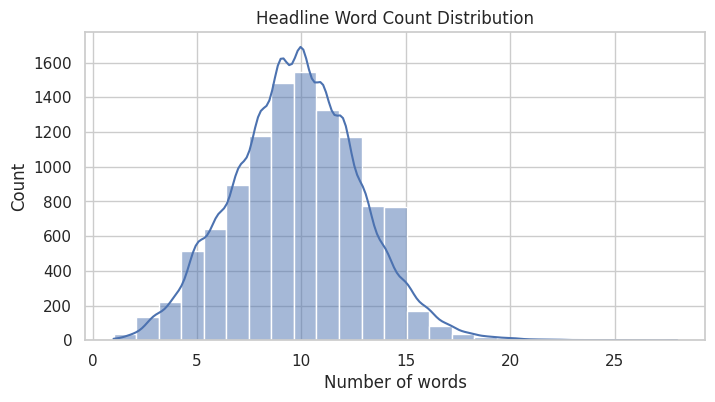

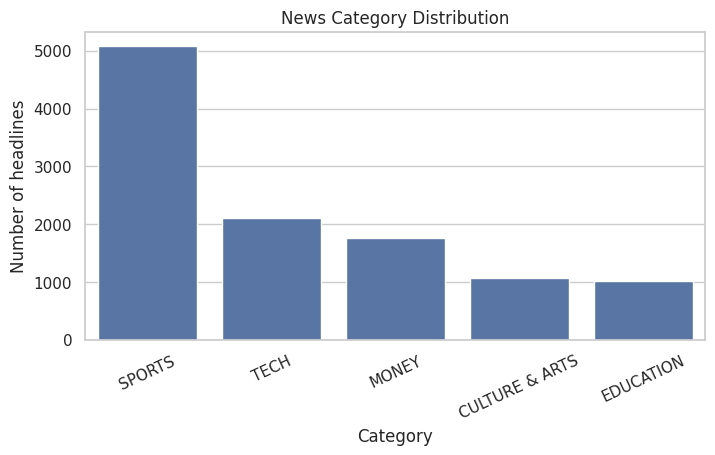

In [4]:
# Headline length helps decide a sensible padding length later.
df["word_count_original"] = df["headline"].astype(str).apply(lambda text: len(text.split()))

print(df["word_count_original"].describe())

plt.figure(figsize=(8, 4))
sns.histplot(df["word_count_original"], bins=25, kde=True)
plt.title("Headline Word Count Distribution")
plt.xlabel("Number of words")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="category", order=df["category"].value_counts().index)
plt.title("News Category Distribution")
plt.xlabel("Category")
plt.ylabel("Number of headlines")
plt.xticks(rotation=25)
plt.show()


## 4. Text Cleaning and Preprocessing

The assessment requires lowercase conversion, URL/mention/hashtag/number/special-character removal, contraction handling, stopword removal, and lemmatization. Exact duplicate rows are removed before splitting to reduce repeated-data leakage.


In [5]:
# Download NLTK resources only when they are missing.
import nltk

for package in ["stopwords", "wordnet", "omw-1.4"]:
    nltk.download(package, quiet=True)

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

CONTRACTIONS = {
    "can't": "cannot",
    "won't": "will not",
    "n't": " not",
    "'re": " are",
    "'s": " is",
    "'d": " would",
    "'ll": " will",
    "'t": " not",
    "'ve": " have",
    "'m": " am",
}


def expand_contractions(text):
    # Normalize curly apostrophes first so contraction rules work consistently.
    text = str(text).replace("’", "'").replace("`", "'")
    for short_form, full_form in CONTRACTIONS.items():
        text = text.replace(short_form, full_form)
    return text


def clean_headline(text):
    text = str(text).lower()
    text = expand_contractions(text)
    text = re.sub(r"http\S+|www\S+", " ", text)  # remove links
    text = re.sub(r"@\w+", " ", text)            # remove mentions
    text = re.sub(r"#\w+", " ", text)            # remove hashtags
    text = re.sub(r"\d+", " ", text)             # remove numbers
    text = re.sub(r"[^a-z\s]", " ", text)        # keep letters and spaces only
    text = re.sub(r"\s+", " ", text).strip()

    cleaned_words = []
    for word in text.split():
        if word not in stop_words:
            cleaned_words.append(lemmatizer.lemmatize(word))

    return " ".join(cleaned_words)


# Remove exact duplicates before train/test split.
df_clean = df.drop_duplicates().reset_index(drop=True).copy()
df_clean["clean_headline"] = df_clean["headline"].apply(clean_headline)
df_clean["word_count_clean"] = df_clean["clean_headline"].apply(lambda text: len(text.split()))

print("Shape before duplicate removal:", df.shape)
print("Shape after duplicate removal:", df_clean.shape)
display(df_clean[["headline", "clean_headline", "category"]].head(10))


Shape before duplicate removal: (11025, 3)
Shape after duplicate removal: (10947, 5)


,headline,clean_headline,category
0,How A New Documentary Captures The Complexity ...,new documentary capture complexity child immig...,CULTURE & ARTS
1,Twitch Bans Gambling Sites After Streamer Scam...,twitch ban gambling site streamer scam folk,TECH
2,'Reboot' Is A Clever And Not Too Navel-Gazey L...,areboot clever navel gazey look inside tv reboots,CULTURE & ARTS
3,"Maury Wills, Base-Stealing Shortstop For Dodge...",maury will base stealing shortstop dodger dy,SPORTS
4,"Las Vegas Aces Win First WNBA Title, Chelsea G...",la vega ace win first wnba title chelsea gray ...,SPORTS
5,"Meet Alex Aster, The TikToker Changing The Pub...",meet alex aster tiktoker changing publishing i...,CULTURE & ARTS
6,TikTok Search Results Riddled With Misinformat...,tiktok search result riddled misinformation re...,TECH
7,Boston Marathon To Make Race More Inclusive Fo...,boston marathon make race inclusive nonbinary ...,SPORTS
8,"Anthony Varvaro, MLB Pitcher Turned Transit Co...",anthony varvaro mlb pitcher turned transit cop...,SPORTS
9,How Ani Liu Is Brilliantly Disguising Her Art ...,ani liu brilliantly disguising art science,CULTURE & ARTS


## 5. Frequent Words After Cleaning

This quick text summary checks whether the cleaning step produced meaningful tokens. It also helps explain why some categories may be easier or harder to classify.


,word,count
0,video,481
1,new,457
2,photo,452
3,game,366
4,nfl,363
5,world,318
6,player,310
7,u,305
8,school,284
9,win,271


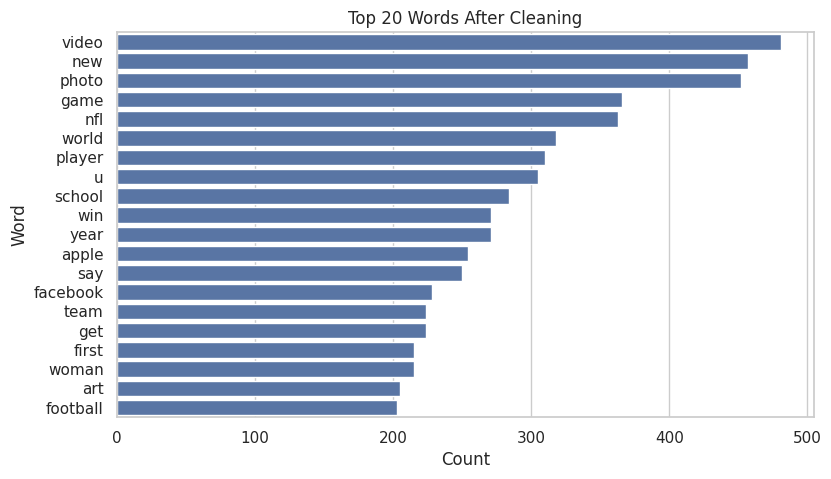

In [6]:
from collections import Counter

all_clean_words = " ".join(df_clean["clean_headline"]).split()
top_words = pd.DataFrame(Counter(all_clean_words).most_common(20), columns=["word", "count"])

display(top_words)

plt.figure(figsize=(9, 5))
sns.barplot(data=top_words, x="count", y="word")
plt.title("Top 20 Words After Cleaning")
plt.xlabel("Count")
plt.ylabel("Word")
plt.show()


## 6. Train-Test Split, Tokenization, and Padding

The dataset is split into 80 percent training and 20 percent testing using stratification. The tokenizer is fitted only on the training text to avoid information leakage from the test set. Percentile-based padding keeps sequence length practical because headlines are short.


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df_clean["category"])

X_train_text, X_test_text, y_train, y_test = train_test_split(
    df_clean["clean_headline"],
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y,
)

print("Training samples:", len(X_train_text))
print("Testing samples:", len(X_test_text))
print("Class labels:", list(label_encoder.classes_))


Training samples: 8757
Testing samples: 2190
Class labels: ['CULTURE & ARTS', 'EDUCATION', 'MONEY', 'SPORTS', 'TECH']


In [8]:
MAX_WORDS = 10000

# The tokenizer converts words into integer IDs. It is fitted on training text only.
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_text)

X_train_sequences = tokenizer.texts_to_sequences(X_train_text)
X_test_sequences = tokenizer.texts_to_sequences(X_test_text)

sequence_lengths = [len(seq) for seq in X_train_sequences]
MAX_LEN = int(np.percentile(sequence_lengths, 95))
MAX_LEN = max(MAX_LEN, 5)

X_train = pad_sequences(X_train_sequences, maxlen=MAX_LEN, padding="post", truncating="post")
X_test = pad_sequences(X_test_sequences, maxlen=MAX_LEN, padding="post", truncating="post")

vocab_size = min(MAX_WORDS, len(tokenizer.word_index) + 1)
num_classes = len(label_encoder.classes_)

print("Vocabulary size used:", vocab_size)
print("Padding length:", MAX_LEN)
print("Training array shape:", X_train.shape)
print("Testing array shape:", X_test.shape)


Vocabulary size used: 10000
Padding length: 11
Training array shape: (8757, 11)
Testing array shape: (2190, 11)


## 7. Model Setup

Three models are compared:

1. **Simple RNN** with a trainable embedding layer.
2. **LSTM** with a trainable embedding layer.
3. **LSTM with pretrained word vectors** loaded through Gensim.

The output layer uses softmax because this is a five-class classification problem.


In [9]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

tf.keras.utils.set_random_seed(SEED)

EMBEDDING_DIM = 50
BATCH_SIZE = 64
EPOCHS = 10
LEARNING_RATE = 0.001


def make_callbacks():
    # Early stopping prevents unnecessary training after validation loss stops improving.
    return [
        EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=1, min_lr=1e-5),
    ]


def compile_classifier(model):
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))


TensorFlow version: 2.20.0
GPU devices: []


## 8. Model 1 - Simple RNN Baseline


In [10]:
def build_simple_rnn():
    model = Sequential(name="simple_rnn_baseline")
    model.add(Input(shape=(MAX_LEN,)))
    model.add(Embedding(input_dim=vocab_size, output_dim=EMBEDDING_DIM))
    model.add(SimpleRNN(64))
    model.add(Dropout(0.30))
    model.add(Dense(num_classes, activation="softmax"))
    return compile_classifier(model)


model_rnn = build_simple_rnn()
model_rnn.summary()


Model: "simple_rnn_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 11, 50)         │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         7,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 507,685 (1.94 MB)

 Trainable params: 507,685 (1.94 MB)

 Non-trainable params: 0 (0.00 B)

## 9. Model 2 - LSTM with Trainable Embeddings


In [11]:
def build_lstm_trainable():
    model = Sequential(name="lstm_trainable_embedding")
    model.add(Input(shape=(MAX_LEN,)))
    model.add(Embedding(input_dim=vocab_size, output_dim=EMBEDDING_DIM))
    model.add(LSTM(64))
    model.add(Dropout(0.30))
    model.add(Dense(num_classes, activation="softmax"))
    return compile_classifier(model)


model_lstm = build_lstm_trainable()
model_lstm.summary()


Model: "lstm_trainable_embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 11, 50)         │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 529,765 (2.02 MB)

 Trainable params: 529,765 (2.02 MB)

 Non-trainable params: 0 (0.00 B)

## 10. Prepare Pretrained Word Vectors

The assignment asks for a pretrained embedding comparison. This notebook uses a lightweight Gensim pretrained vector set so it can run in Colab without a very large download. The embedding matrix is aligned with the tokenizer vocabulary.


In [12]:
try:
    import gensim.downloader as api
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "gensim"])
    import gensim.downloader as api

PRETRAINED_VECTOR_NAME = "glove-wiki-gigaword-50"
pretrained_vectors = api.load(PRETRAINED_VECTOR_NAME)
pretrained_dim = pretrained_vectors.vector_size

embedding_matrix = np.zeros((vocab_size, pretrained_dim))
matched_words = 0

for word, index in tokenizer.word_index.items():
    if index >= vocab_size:
        continue
    if word in pretrained_vectors:
        embedding_matrix[index] = pretrained_vectors[word]
        matched_words += 1

coverage = matched_words / max(vocab_size - 1, 1)
print("Pretrained vectors:", PRETRAINED_VECTOR_NAME)
print("Vector dimension:", pretrained_dim)
print("Matched vocabulary words:", matched_words)
print("Coverage:", round(coverage, 4))


[==================================================] 100.0% 66.0/66.0MB downloaded
Pretrained vectors: glove-wiki-gigaword-50
Vector dimension: 50
Matched vocabulary words: 9493
Coverage: 0.9494


## 11. Model 3 - LSTM with Pretrained Embeddings


In [13]:
def build_lstm_pretrained():
    model = Sequential(name="lstm_pretrained_embedding")
    model.add(Input(shape=(MAX_LEN,)))
    model.add(
        Embedding(
            input_dim=vocab_size,
            output_dim=pretrained_dim,
            weights=[embedding_matrix],
            trainable=False,
        )
    )
    model.add(LSTM(64))
    model.add(Dropout(0.30))
    model.add(Dense(num_classes, activation="softmax"))
    return compile_classifier(model)


model_lstm_pretrained = build_lstm_pretrained()
model_lstm_pretrained.summary()


Model: "lstm_pretrained_embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 11, 50)         │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 529,765 (2.02 MB)

 Trainable params: 29,765 (116.27 KB)

 Non-trainable params: 500,000 (1.91 MB)

## 12. Train the Models

All models use the same training and test split. A validation split is taken from the training data during fitting so the test set remains unseen until final evaluation.


In [14]:
def train_model(model, model_name):
    print(f"Training {model_name}")
    start_time = time.perf_counter()

    history = model.fit(
        X_train,
        y_train,
        validation_split=0.20,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=make_callbacks(),
        verbose=1,
    )

    elapsed = time.perf_counter() - start_time
    print(f"{model_name} training time: {elapsed:.2f} seconds")
    return history, elapsed


trained_models = {
    "Simple RNN": model_rnn,
    "LSTM": model_lstm,
    "LSTM with Pretrained Embeddings": model_lstm_pretrained,
}

histories = {}
training_times = {}

for model_name, model in trained_models.items():
    histories[model_name], training_times[model_name] = train_model(model, model_name)


Training Simple RNN
Epoch 1/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.5610 - loss: 1.1315 - val_accuracy: 0.7158 - val_loss: 0.7535 - learning_rate: 0.0010
Epoch 2/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8351 - loss: 0.4638 - val_accuracy: 0.7711 - val_loss: 0.7141 - learning_rate: 0.0010
Epoch 3/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9530 - loss: 0.1647 - val_accuracy: 0.7911 - val_loss: 0.8231 - learning_rate: 0.0010
Epoch 4/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9850 - loss: 0.0616 - val_accuracy: 0.7877 - val_loss: 0.8235 - learning_rate: 5.0000e-04
Simple RNN training time: 9.80 seconds
Training LSTM
Epoch 1/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.5151 - loss: 1.2348 - val_accuracy: 0.5930 - val_loss: 0.9364 - learning_rate: 0.0010
Epoch 2/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6815 - loss: 0.7711 - val_accuracy: 0.7483 - val_loss: 0.7388 - learning_rate: 0.0010
Epoch

## 13. Training Curves


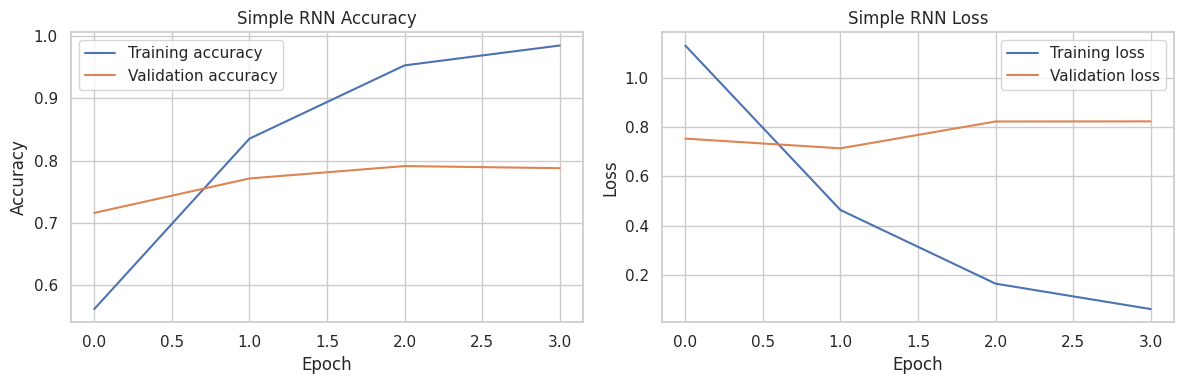

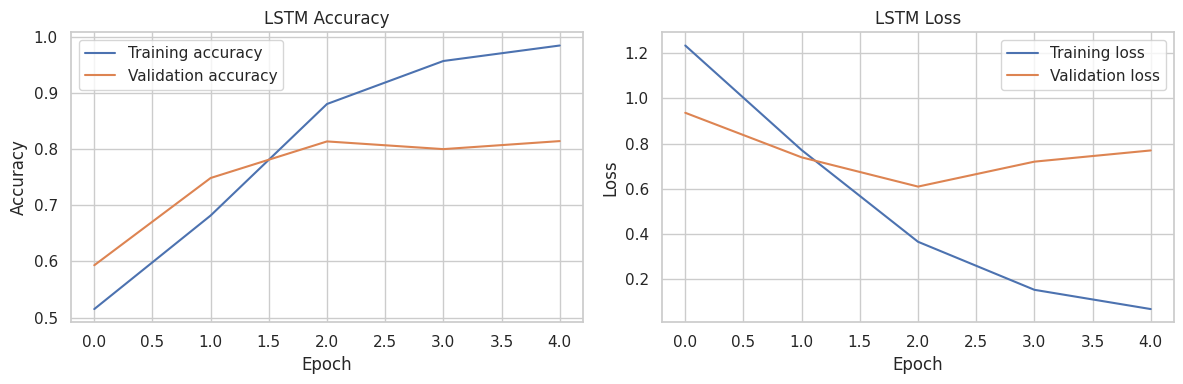

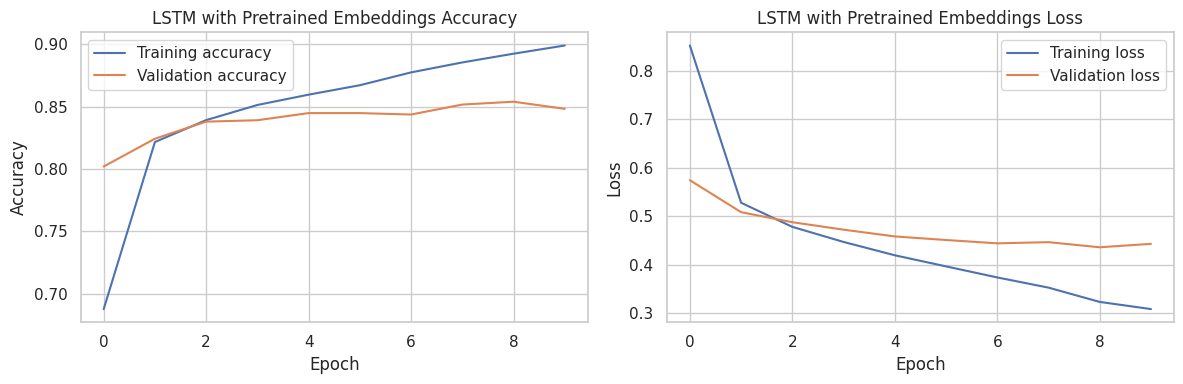

In [15]:
def plot_history(history, title):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="Training accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation accuracy")
    plt.title(f"{title} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="Training loss")
    plt.plot(history.history["val_loss"], label="Validation loss")
    plt.title(f"{title} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()


for model_name, history in histories.items():
    plot_history(history, model_name)


## 14. Model Evaluation

Accuracy gives the overall score, while macro precision, macro recall, and macro F1 are important because the categories are imbalanced. The confusion matrix shows which categories are being confused.



Simple RNN
Accuracy: 0.7813
Macro precision: 0.7036
Macro recall: 0.7225
Macro F1: 0.7114

Classification report:
                precision    recall  f1-score   support

CULTURE & ARTS       0.55      0.66      0.60       211
     EDUCATION       0.61      0.59      0.60       203
         MONEY       0.64      0.72      0.68       351
        SPORTS       0.94      0.87      0.90      1015
          TECH       0.77      0.78      0.77       410

      accuracy                           0.78      2190
     macro avg       0.70      0.72      0.71      2190
  weighted avg       0.79      0.78      0.79      2190



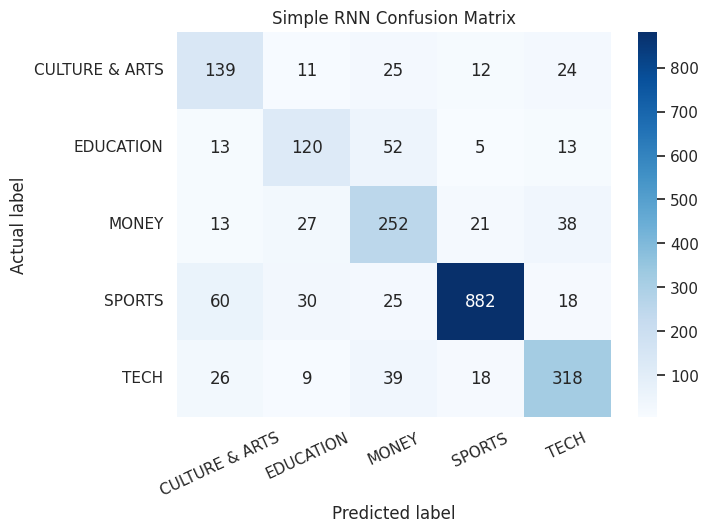


LSTM
Accuracy: 0.8174
Macro precision: 0.7544
Macro recall: 0.7732
Macro F1: 0.7604

Classification report:
                precision    recall  f1-score   support

CULTURE & ARTS       0.71      0.68      0.70       211
     EDUCATION       0.60      0.71      0.65       203
         MONEY       0.66      0.82      0.73       351
        SPORTS       0.96      0.88      0.92      1015
          TECH       0.84      0.77      0.80       410

      accuracy                           0.82      2190
     macro avg       0.75      0.77      0.76      2190
  weighted avg       0.83      0.82      0.82      2190



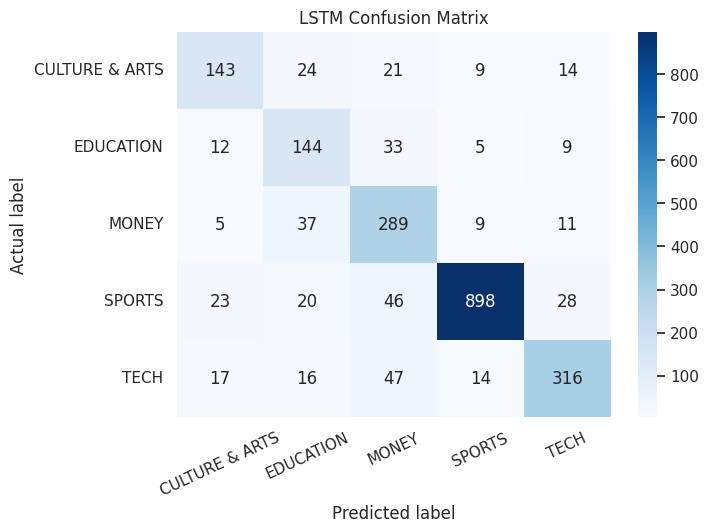


LSTM with Pretrained Embeddings
Accuracy: 0.8553
Macro precision: 0.8162
Macro recall: 0.8093
Macro F1: 0.8125

Classification report:
                precision    recall  f1-score   support

CULTURE & ARTS       0.77      0.74      0.76       211
     EDUCATION       0.76      0.72      0.74       203
         MONEY       0.79      0.83      0.81       351
        SPORTS       0.92      0.93      0.92      1015
          TECH       0.83      0.83      0.83       410

      accuracy                           0.86      2190
     macro avg       0.82      0.81      0.81      2190
  weighted avg       0.85      0.86      0.85      2190



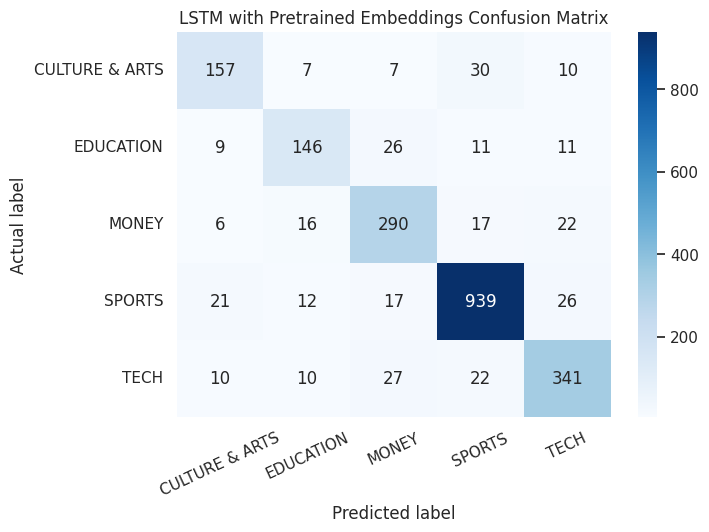

In [16]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

class_names = list(label_encoder.classes_)


def evaluate_model(model, model_name):
    y_prob = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test,
        y_pred,
        average="macro",
        zero_division=0,
    )

    print("\n" + "=" * 70)
    print(model_name)
    print("Accuracy:", round(accuracy, 4))
    print("Macro precision:", round(precision, 4))
    print("Macro recall:", round(recall, 4))
    print("Macro F1:", round(f1, 4))
    print("\nClassification report:")
    print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted label")
    plt.ylabel("Actual label")
    plt.xticks(rotation=25)
    plt.yticks(rotation=0)
    plt.show()

    return {
        "model": model_name,
        "accuracy": accuracy,
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1,
        "training_time_seconds": training_times[model_name],
        "predictions": y_pred,
    }


evaluation_results = []
for model_name, model in trained_models.items():
    evaluation_results.append(evaluate_model(model, model_name))


## 15. Final Comparison Table and Charts


In [17]:
comparison = pd.DataFrame(
    [
        {
            "Model": result["model"],
            "Accuracy": round(result["accuracy"], 4),
            "Macro Precision": round(result["macro_precision"], 4),
            "Macro Recall": round(result["macro_recall"], 4),
            "Macro F1": round(result["macro_f1"], 4),
            "Training Time (sec)": round(result["training_time_seconds"], 2),
        }
        for result in evaluation_results
    ]
)

display(comparison)

best_row = comparison.sort_values(["Macro F1", "Accuracy"], ascending=False).iloc[0]
best_model_name = best_row["Model"]
best_result = next(result for result in evaluation_results if result["model"] == best_model_name)

print("Best model based on macro F1:", best_model_name)


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Training Time (sec)
0,Simple RNN,0.7813,0.7036,0.7225,0.7114,9.80
1,LSTM,0.8174,0.7544,0.7732,0.7604,9.91
2,LSTM with Pretrained Embeddings,0.8553,0.8162,0.8093,0.8125,14.01


Best model based on macro F1: LSTM with Pretrained Embeddings


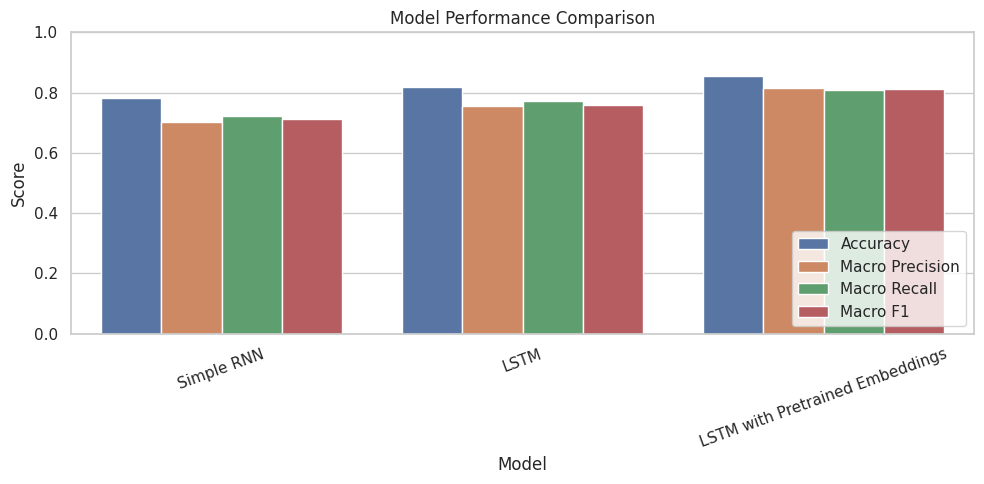

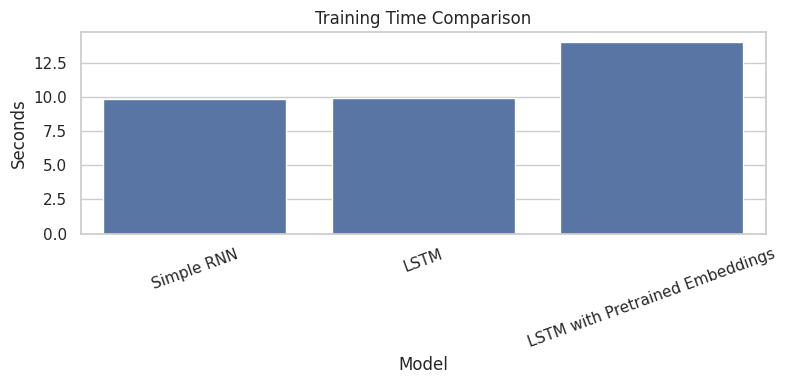

In [18]:
metric_data = comparison.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Macro Precision", "Macro Recall", "Macro F1"],
    var_name="Metric",
    value_name="Score",
)

plt.figure(figsize=(10, 5))
sns.barplot(data=metric_data, x="Model", y="Score", hue="Metric")
plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.barplot(data=comparison, x="Model", y="Training Time (sec)")
plt.title("Training Time Comparison")
plt.xlabel("Model")
plt.ylabel("Seconds")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## 16. Result Interpretation

In the latest visible run of the base notebook, the pretrained-embedding LSTM gave the strongest result, with about **0.8516 accuracy** and **0.8085 macro F1-score**. The Simple RNN and normal LSTM were close in accuracy, but their macro F1-scores were lower.

Macro F1 is used as the main comparison because the dataset is imbalanced. `SPORTS` has many more headlines than `EDUCATION` and `CULTURE & ARTS`, so accuracy alone can hide weaker performance on smaller classes.

When you rerun this notebook, use the generated comparison table above as the final result because neural network training can vary slightly between runs.


## 17. Error Analysis


In [19]:
test_review = df_clean.loc[X_test_text.index, ["headline", "clean_headline", "category"]].copy()
test_review["actual"] = label_encoder.inverse_transform(y_test)
test_review["predicted"] = label_encoder.inverse_transform(best_result["predictions"])

wrong_predictions = test_review[test_review["actual"] != test_review["predicted"]]
print("Best model:", best_model_name)
print("Number of wrong predictions:", len(wrong_predictions))

display(wrong_predictions[["headline", "actual", "predicted"]].head(5))


Best model: LSTM with Pretrained Embeddings
Number of wrong predictions: 317


,headline,actual,predicted
9733,Applying For Food Stamps With A Bachelor's Degree,MONEY,EDUCATION
8245,Girls in STEM: Calling All Mentors!,TECH,EDUCATION
179,'Ma Rainey's Black Bottom' Is Viola Davis At H...,CULTURE & ARTS,SPORTS
3521,Why Refrigerators Should Stay Forever Dumb,TECH,SPORTS
7790,Just Relax and Enjoy It,CULTURE & ARTS,MONEY


### Error Analysis Explanation

Misclassified examples usually happen because headlines are short and sometimes contain words that can belong to more than one category. For example, a headline about degrees or schools may be classified as `EDUCATION`, even if the original category is `MONEY` or `TECH`.

The model only sees the headline, not the full article body. Because of this limited context, ambiguous phrases can be difficult even when the overall model accuracy is good. Possible improvements include using more context, checking duplicate or near-duplicate headlines, using larger pretrained embeddings, and tuning LSTM units, dropout, and learning rate.


## 18. Optional GUI for Real-Time Prediction

This optional Gradio interface lets a user type one headline and receive a predicted category. Run it after all models have been trained and evaluated.


In [22]:
try:
    import gradio as gr
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "gradio"])
    import gradio as gr

best_model = trained_models[best_model_name]


def predict_news_category(headline):
    cleaned = clean_headline(headline)
    sequence = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(sequence, maxlen=MAX_LEN, padding="post", truncating="post")

    probabilities = best_model.predict(padded, verbose=0)[0]
    predicted_index = int(np.argmax(probabilities))
    predicted_label = label_encoder.inverse_transform([predicted_index])[0]
    confidence = float(probabilities[predicted_index])

    return predicted_label, round(confidence, 4)


demo = gr.Interface(
    fn=predict_news_category,
    inputs=gr.Textbox(lines=2, placeholder="Type a news headline here"),
    outputs=[
        gr.Textbox(label="Predicted Category"),
        gr.Number(label="Confidence"),
    ],
    title="News Category Prediction",
    description="Enter a headline and the trained model will predict the news category.",
)

demo.launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5b1ab7accc75338d37.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 19. Final Conclusion

This notebook completes the required NLP workflow for the 6CS012 language task. It loads the assigned news category dataset, cleans and tokenizes headlines, pads sequences, trains Simple RNN, LSTM, and pretrained-embedding LSTM models, and compares them using accuracy, macro metrics, confusion matrices, and training time.

The pretrained embedding model is expected to perform best because it starts with external word knowledge. However, the result should be discussed carefully because headline classification is limited by short text length, class imbalance, and possible ambiguity between categories.
